=== Decision Tree Regression Implementation ===

1. Loading California Housing Dataset...
Dataset shape: (20640, 8)
Target variable range: $0.15 - $5.00 (in hundreds of thousands)

Feature descriptions:
- MedInc: Missing Attribute Values
- HouseAge: None

This dataset was obtained from the StatLib repository.
https
- AveRooms: //www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block group is the smallest geographical unit for which the U.S.
Census Bureau publishes sample data (a block group typically has a population
of 600 to 3,000 people).

A household is a group of people residing within a home. Since the average
number of rooms and bedrooms in this dataset are provided per household, these
columns may take surprisingly large values for block groups with few 

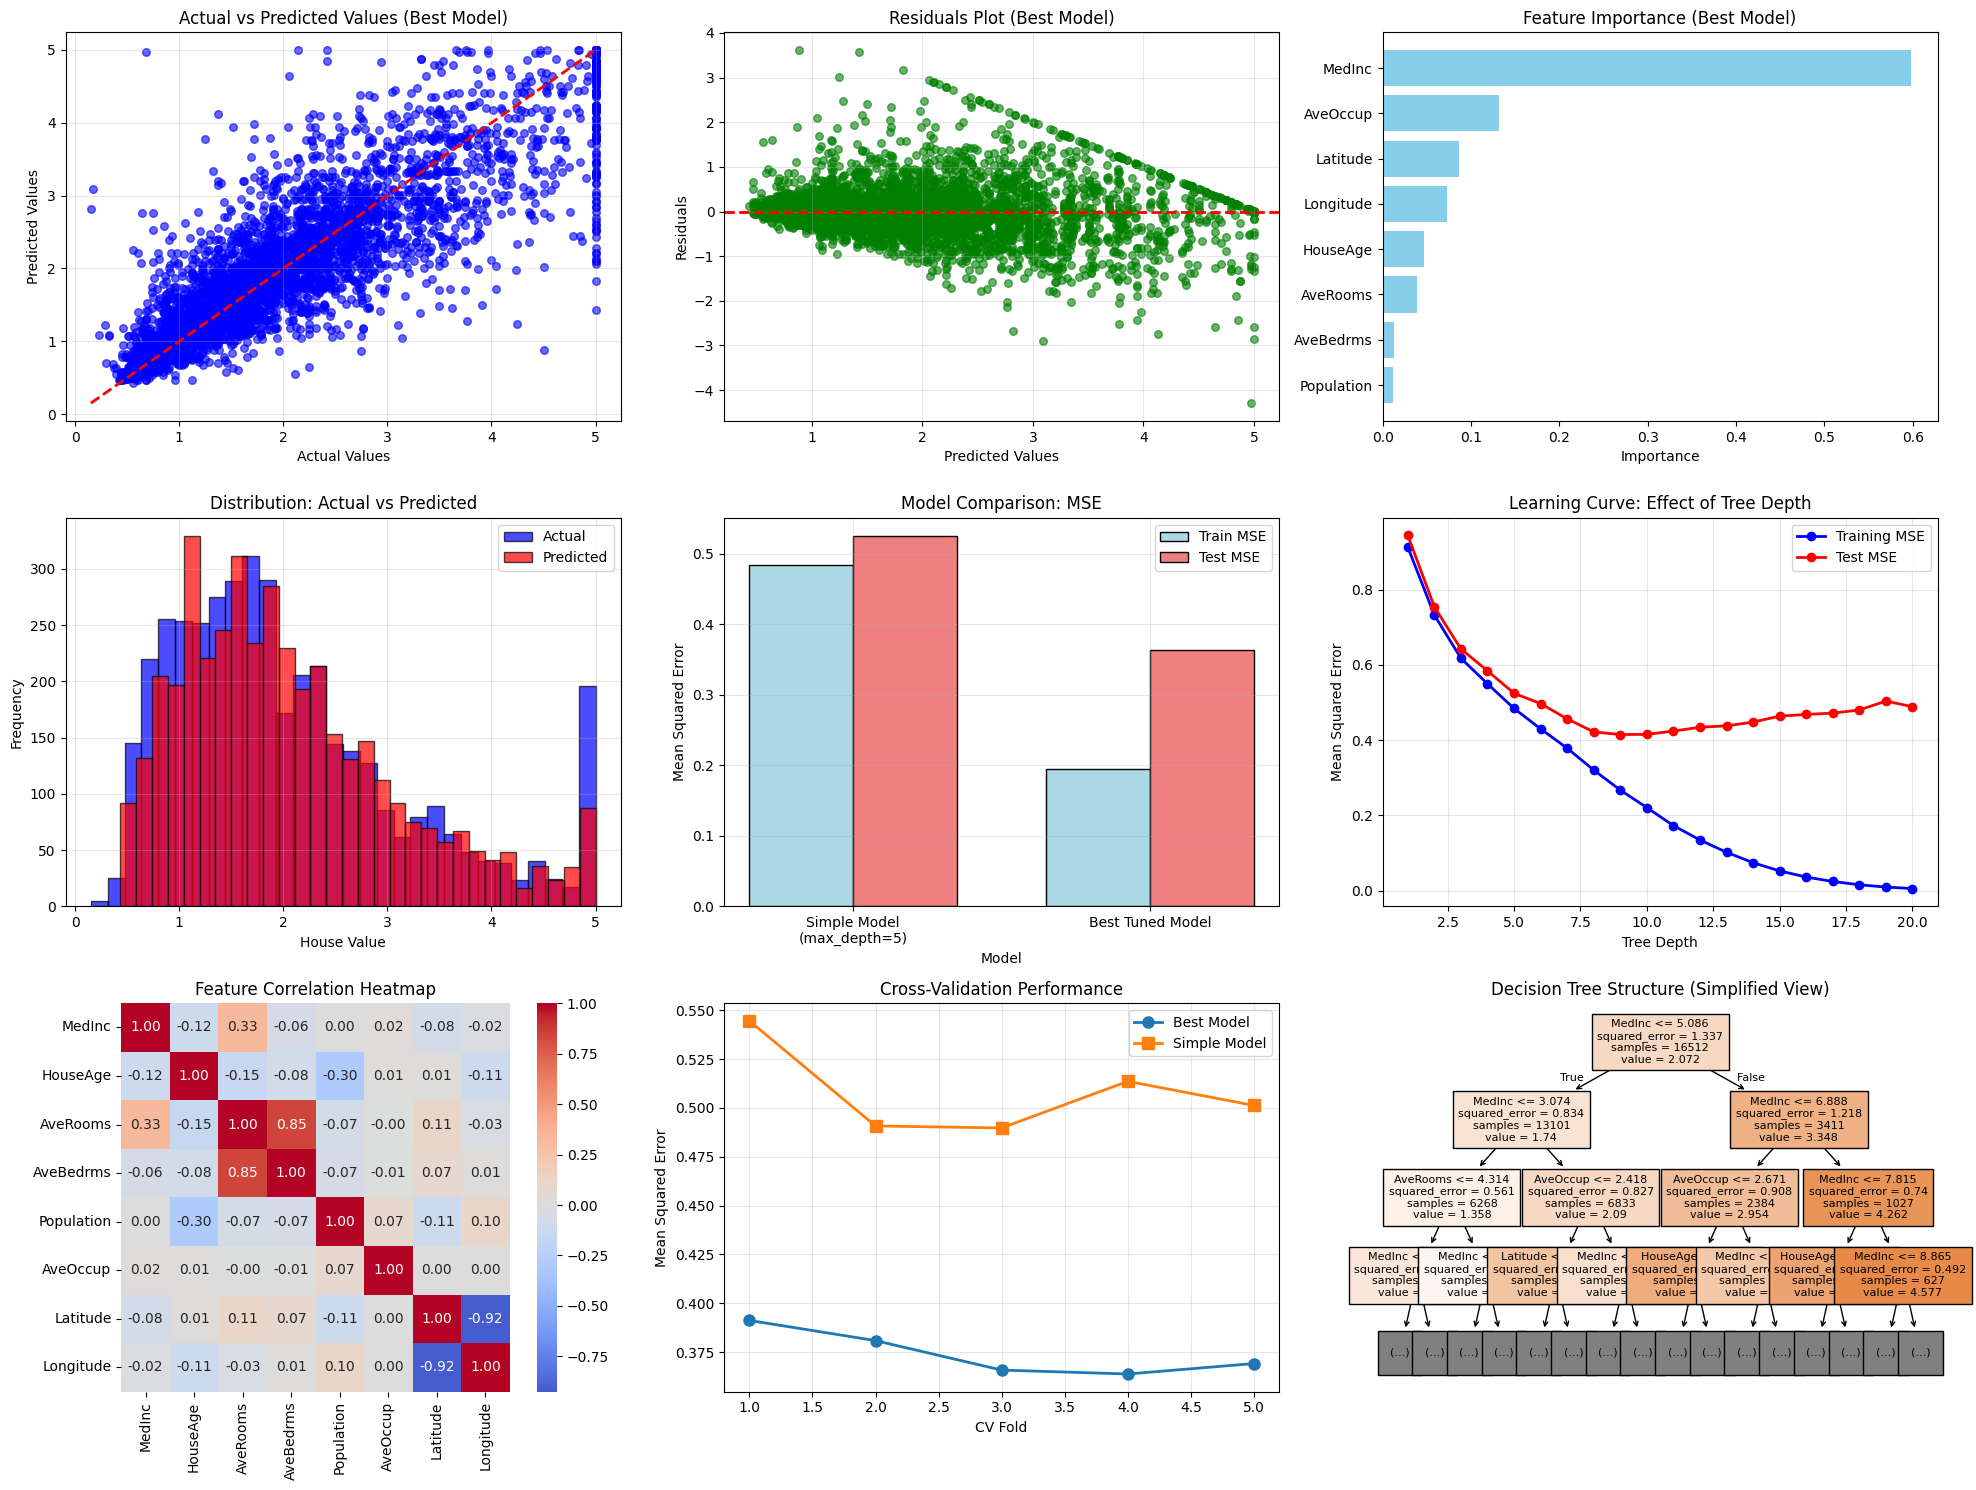


8. Model Analysis and Insights...

Overfitting Analysis:
Best Model - Train R²: 0.8541, Test R²: 0.7227
Simple Model - Train R²: 0.6377, Test R²: 0.5997
Overfitting Gap (Best): 0.1314
Overfitting Gap (Simple): 0.0379

Model Complexity:
Best Model - Tree Depth: 15, Leaves: 1208
Simple Model - Tree Depth: 5, Leaves: 32

Key Insights:
• Most important feature: MedInc (0.598)
• Least important feature: Population (0.011)

Final Model Performance Summary:
• Best model RMSE on test set: $0.60 (hundreds of thousands)
• This represents an average prediction error of ~$60277
• Model explains 72.3% of the variance in house prices

=== Analysis Complete ===


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("=== Decision Tree Regression Implementation ===\n")

# 1. LOAD AND EXPLORE DATASET
print("1. Loading California Housing Dataset...")
# Load the California housing dataset - perfect for regression
california_housing = fetch_california_housing()
X = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
y = pd.Series(california_housing.target, name='MedHouseValue')

print(f"Dataset shape: {X.shape}")
print(f"Target variable range: ${y.min():.2f} - ${y.max():.2f} (in hundreds of thousands)")
print("\nFeature descriptions:")
for i, feature in enumerate(california_housing.feature_names):
    print(f"- {feature}: {california_housing.DESCR.split('Attribute Information:')[1].split(':')[i+1].split('-')[0].strip()}")

# Display basic statistics
print("\nDataset Info:")
print(X.describe().round(2))
print(f"\nTarget variable statistics:")
print(y.describe().round(2))

# 2. DATA PREPROCESSING
print("\n2. Data Preprocessing...")

# Check for missing values
print(f"Missing values in features: {X.isnull().sum().sum()}")
print(f"Missing values in target: {y.isnull().sum()}")

# Feature correlation analysis
print("\nFeature correlation with target:")
correlations = X.corrwith(y).sort_values(ascending=False)
print(correlations.round(3))

# 3. TRAIN-TEST SPLIT
print("\n3. Splitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# 4. MODEL TRAINING WITH HYPERPARAMETER TUNING
print("\n4. Training Decision Tree Regressor with Hyperparameter Tuning...")

# Define hyperparameter grid for optimization
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['auto', 'sqrt', 'log2', None]
}

# Initialize the regressor
dt_regressor = DecisionTreeRegressor(random_state=42)

# Perform grid search with cross-validation
print("Performing Grid Search with 5-fold Cross Validation...")
grid_search = GridSearchCV(
    estimator=dt_regressor,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Get the best model
best_dt = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score (negative MSE): {grid_search.best_score_:.4f}")

# Train a simple model for comparison
simple_dt = DecisionTreeRegressor(max_depth=5, random_state=42)
simple_dt.fit(X_train, y_train)

# 5. MODEL EVALUATION
print("\n5. Model Evaluation...")

# Make predictions
y_train_pred_best = best_dt.predict(X_train)
y_test_pred_best = best_dt.predict(X_test)
y_train_pred_simple = simple_dt.predict(X_train)
y_test_pred_simple = simple_dt.predict(X_test)

# Calculate metrics for both models
def calculate_metrics(y_true, y_pred, model_name, dataset_type):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} - {dataset_type} Set Metrics:")
    print(f"  Mean Squared Error (MSE): {mse:.4f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  R² Score: {r2:.4f}")
    
    return mse, rmse, mae, r2

# Evaluate both models
calculate_metrics(y_train, y_train_pred_best, "Best Tuned Model", "Training")
calculate_metrics(y_test, y_test_pred_best, "Best Tuned Model", "Test")
calculate_metrics(y_train, y_train_pred_simple, "Simple Model", "Training")
calculate_metrics(y_test, y_test_pred_simple, "Simple Model", "Test")

# Cross-validation scores
cv_scores_best = cross_val_score(best_dt, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_scores_simple = cross_val_score(simple_dt, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

print(f"\nCross-validation RMSE (Best Model): {np.sqrt(-cv_scores_best.mean()):.4f} (+/- {np.sqrt(cv_scores_best.std() * 2):.4f})")
print(f"Cross-validation RMSE (Simple Model): {np.sqrt(-cv_scores_simple.mean()):.4f} (+/- {np.sqrt(cv_scores_simple.std() * 2):.4f})")

# 6. FEATURE IMPORTANCE ANALYSIS
print("\n6. Feature Importance Analysis...")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance_best': best_dt.feature_importances_,
    'importance_simple': simple_dt.feature_importances_
}).sort_values('importance_best', ascending=False)

print("Top 5 Most Important Features (Best Model):")
print(feature_importance.head())

# 7. VISUALIZATIONS
print("\n7. Generating Visualizations...")

# Set up the plotting style
plt.style.use('default')
fig = plt.figure(figsize=(20, 15))

# Plot 1: Actual vs Predicted (Best Model)
plt.subplot(3, 3, 1)
plt.scatter(y_test, y_test_pred_best, alpha=0.6, color='blue', s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Best Model)')
plt.grid(True, alpha=0.3)

# Plot 2: Residuals Plot (Best Model)
plt.subplot(3, 3, 2)
residuals = y_test - y_test_pred_best
plt.scatter(y_test_pred_best, residuals, alpha=0.6, color='green', s=30)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot (Best Model)')
plt.grid(True, alpha=0.3)

# Plot 3: Feature Importance
plt.subplot(3, 3, 3)
plt.barh(feature_importance['feature'], feature_importance['importance_best'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance (Best Model)')
plt.gca().invert_yaxis()

# Plot 4: Prediction Distribution
plt.subplot(3, 3, 4)
plt.hist(y_test, bins=30, alpha=0.7, label='Actual', color='blue', edgecolor='black')
plt.hist(y_test_pred_best, bins=30, alpha=0.7, label='Predicted', color='red', edgecolor='black')
plt.xlabel('House Value')
plt.ylabel('Frequency')
plt.title('Distribution: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Model Comparison (MSE)
plt.subplot(3, 3, 5)
models = ['Simple Model\n(max_depth=5)', 'Best Tuned Model']
train_mse = [mean_squared_error(y_train, y_train_pred_simple), mean_squared_error(y_train, y_train_pred_best)]
test_mse = [mean_squared_error(y_test, y_test_pred_simple), mean_squared_error(y_test, y_test_pred_best)]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, train_mse, width, label='Train MSE', color='lightblue', edgecolor='black')
plt.bar(x + width/2, test_mse, width, label='Test MSE', color='lightcoral', edgecolor='black')

plt.xlabel('Model')
plt.ylabel('Mean Squared Error')
plt.title('Model Comparison: MSE')
plt.xticks(x, models)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: Learning Curve (Tree Depth)
plt.subplot(3, 3, 6)
depths = range(1, 21)
train_scores = []
test_scores = []

for depth in depths:
    dt_temp = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    train_scores.append(mean_squared_error(y_train, dt_temp.predict(X_train)))
    test_scores.append(mean_squared_error(y_test, dt_temp.predict(X_test)))

plt.plot(depths, train_scores, 'o-', color='blue', label='Training MSE', linewidth=2)
plt.plot(depths, test_scores, 'o-', color='red', label='Test MSE', linewidth=2)
plt.xlabel('Tree Depth')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve: Effect of Tree Depth')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 7: Correlation Heatmap
plt.subplot(3, 3, 7)
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Feature Correlation Heatmap')

# Plot 8: Cross-validation Scores
plt.subplot(3, 3, 8)
cv_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Best Model': -cv_scores_best,
    'Simple Model': -cv_scores_simple
})

plt.plot(cv_results['Fold'], cv_results['Best Model'], 'o-', label='Best Model', linewidth=2, markersize=8)
plt.plot(cv_results['Fold'], cv_results['Simple Model'], 's-', label='Simple Model', linewidth=2, markersize=8)
plt.xlabel('CV Fold')
plt.ylabel('Mean Squared Error')
plt.title('Cross-Validation Performance')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 9: Tree Visualization (Simple Model)
plt.subplot(3, 3, 9)
plot_tree(simple_dt, max_depth=3, feature_names=X.columns, filled=True, fontsize=8)
plt.title('Decision Tree Structure (Simplified View)')

plt.tight_layout()
plt.show()

# 8. DETAILED ANALYSIS AND INSIGHTS
print("\n8. Model Analysis and Insights...")

# Analyze overfitting
train_r2_best = r2_score(y_train, y_train_pred_best)
test_r2_best = r2_score(y_test, y_test_pred_best)
train_r2_simple = r2_score(y_train, y_train_pred_simple)
test_r2_simple = r2_score(y_test, y_test_pred_simple)

print(f"\nOverfitting Analysis:")
print(f"Best Model - Train R²: {train_r2_best:.4f}, Test R²: {test_r2_best:.4f}")
print(f"Simple Model - Train R²: {train_r2_simple:.4f}, Test R²: {test_r2_simple:.4f}")

overfitting_best = train_r2_best - test_r2_best
overfitting_simple = train_r2_simple - test_r2_simple
print(f"Overfitting Gap (Best): {overfitting_best:.4f}")
print(f"Overfitting Gap (Simple): {overfitting_simple:.4f}")

# Model complexity analysis
print(f"\nModel Complexity:")
print(f"Best Model - Tree Depth: {best_dt.get_depth()}, Leaves: {best_dt.get_n_leaves()}")
print(f"Simple Model - Tree Depth: {simple_dt.get_depth()}, Leaves: {simple_dt.get_n_leaves()}")

# Feature importance insights
print(f"\nKey Insights:")
print(f"• Most important feature: {feature_importance.iloc[0]['feature']} ({feature_importance.iloc[0]['importance_best']:.3f})")
print(f"• Least important feature: {feature_importance.iloc[-1]['feature']} ({feature_importance.iloc[-1]['importance_best']:.3f})")

# Performance summary
print(f"\nFinal Model Performance Summary:")
print(f"• Best model RMSE on test set: ${np.sqrt(mean_squared_error(y_test, y_test_pred_best)):.2f} (hundreds of thousands)")
print(f"• This represents an average prediction error of ~${np.sqrt(mean_squared_error(y_test, y_test_pred_best))*100000:.0f}")
print(f"• Model explains {test_r2_best:.1%} of the variance in house prices")

print("\n=== Analysis Complete ===")
